#CELL 1 — INSTALL + IMPORT

In [3]:
# FIX NUMPY COMPATIBILITY
!pip install -q "numpy<2"
!pip install -q roboticstoolbox-python spatialmath-python

from math import pi
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb
from spatialmath import SE3

#CELL 2 — LOAD ROBOT (UR5)

In [2]:
robot = rtb.models.DH.UR5()
print(robot)   # DH parameters → requirement satisfied

DHRobot: UR5 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │ 0.08946 │       0 │  90.0° │
│  q2 │       0 │  -0.425 │   0.0° │
│  q3 │       0 │ -0.3922 │   0.0° │
│  q4 │  0.1091 │       0 │  90.0° │
│  q5 │ 0.09465 │       0 │ -90.0° │
│  q6 │  0.0823 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



#CELL 3 — DEFINE PARAMETERS (reuse Lab 1 fix)

In [3]:
# Ensure non-zero realistic parameters
for link in robot.links:
    link.m = abs(link.m) + 1
    link.B = 0.001
    link.Tc = [0.1, -0.1]

#CELL 4 — INITIAL CONFIGURATION

In [4]:
q_start = [0, -pi/4, pi/6, 0, pi/4, 0]
print("Initial configuration:", q_start)

Initial configuration: [0, -0.7853981633974483, 0.5235987755982988, 0, 0.7853981633974483, 0]


#CELL 5 — FORWARD KINEMATICS

In [5]:
T_start = robot.fkine(q_start)
print("Forward kinematics (End-effector pose):")
print(T_start)

Forward kinematics (End-effector pose):
   0.683     0.2588   -0.683    -0.7601    
  -0.7071    0        -0.7071   -0.1673    
  -0.183     0.9659    0.183     0.4151    
   0         0         0         1         



#CELL 6 — WORKSPACE GENERATION

In [7]:
# DEFINE JOINT LIMITS
qlim = [(-pi, pi)] * 6   # UR5 typical limits

# WORKSPACE SAMPLING
n = 15  # keep small for speed

q_ranges = [
    np.linspace(qlim[i][0], qlim[i][1], n)
    for i in range(3)
]

points = []

for q1 in q_ranges[0]:
    for q2 in q_ranges[1]:
        for q3 in q_ranges[2]:
            T = robot.fkine([q1, q2, q3, 0, 0, 0])
            points.append(T.t)

points = np.array(points)

#CELL 7 — WORKSPACE PLOT

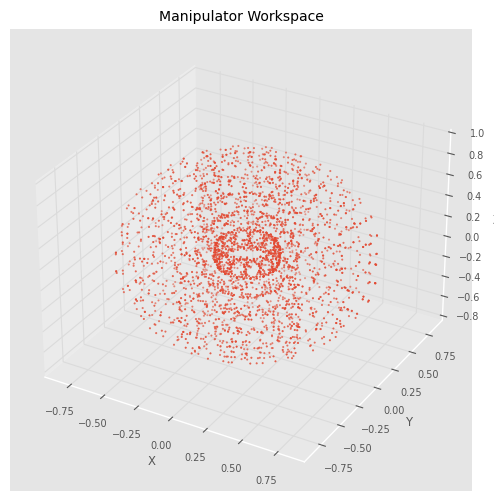

In [8]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(points[:,0], points[:,1], points[:,2], s=1)

ax.set_title("Manipulator Workspace")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

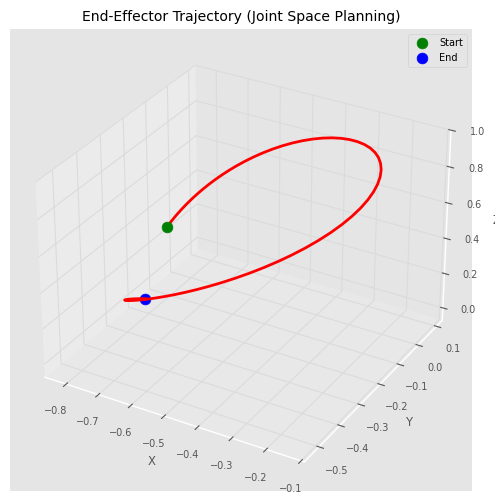

In [17]:
# END-EFFECTOR TRAJECTORY
ee_traj = []

for q in traj1.q:
    T = robot.fkine(q)
    ee_traj.append(T.t)

ee_traj = np.array(ee_traj)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Plot trajectory only (clean)
ax.plot(ee_traj[:,0], ee_traj[:,1], ee_traj[:,2], 'r', linewidth=2)

# Start and End
ax.scatter(ee_traj[0,0], ee_traj[0,1], ee_traj[0,2], c='green', s=60, label='Start')
ax.scatter(ee_traj[-1,0], ee_traj[-1,1], ee_traj[-1,2], c='blue', s=60, label='End')

ax.set_title("End-Effector Trajectory (Joint Space Planning)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
ax.grid(True)

plt.show()

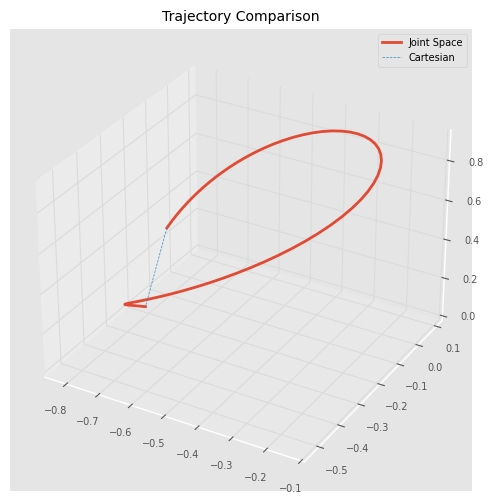

In [20]:
# COMPARE TRAJECTORIES
ee_traj_cart = []

for q in traj2_q:
    T = robot.fkine(q)
    ee_traj_cart.append(T.t)

ee_traj_cart = np.array(ee_traj_cart)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(ee_traj[:,0], ee_traj[:,1], ee_traj[:,2], label='Joint Space', linewidth=2)
ax.plot(ee_traj_cart[:,0], ee_traj_cart[:,1], ee_traj_cart[:,2], linestyle='--', label='Cartesian')

ax.set_title("Trajectory Comparison")
ax.legend()
ax.grid(True)

plt.show()

#CELL 8 — SELECT TARGET POINT

In [18]:
target = points[len(points)//2]  # pick valid workspace point
print("Target point:", target)

Target point: [-0.81725  -0.19145  -0.005191]


#CELL 9 — INVERSE KINEMATICS

In [19]:
T_target = SE3(target)

sol = robot.ikine_LM(T_target)

q_goal = sol.q
print("Inverse kinematics solution:", q_goal)

Inverse kinematics solution: [-2.7810744  -3.01140417 -0.76344752 -0.93753729 -1.57079633  1.21027807]


#CELL 10 — TRAJECTORY PLANNING (3 METHODS)

##Method 1 — Joint Space (jtraj)

In [11]:
t = np.linspace(0, 5, 100)

traj1 = rtb.jtraj(q_start, q_goal, t)

##Method 2 — Cartesian (ctraj)

In [12]:
T_start = robot.fkine(q_start)
T_end   = robot.fkine(q_goal)

traj_cart = rtb.ctraj(T_start, T_end, len(t))

traj2_q = []

for T in traj_cart:
    sol = robot.ikine_LM(T)
    traj2_q.append(sol.q)

traj2_q = np.array(traj2_q)

##Method 3 — Linear Interpolation

In [13]:
traj3_q = np.linspace(q_start, q_goal, len(t))

#CELL 11 — VELOCITY + ACCELERATION COMPUTATION

In [33]:
# --- FUNCTION FOR NUMERICAL DERIVATIVES ---
def compute_derivatives(q, t):
    q = np.array(q)
    t = np.array(t)

    qd = np.gradient(q, axis=0) / np.gradient(t)[:, None]
    qdd = np.gradient(qd, axis=0) / np.gradient(t)[:, None]

    return qd, qdd

qd1 = traj1.qd # Joint space (jtraj) — BUILT-IN
qdd1 = traj1.qdd

qd2, qdd2 = compute_derivatives(traj2_q, t) # Cartesian tracjectory (ctraj via IK)

qd3, qdd3 = compute_derivatives(traj3_q, t) # Linear interpolation

#CELL 12 — PLOTS (POSITION, VELOCITY, ACCELERATION)

In [27]:
# PLOT FUNCTION
def plot_joint_separate(t, data, title, ylabel):

    plt.figure(figsize=(10,6))

    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.plot(t, data[:, i], linewidth=2)
        plt.title(f'Joint {i+1}')
        plt.xlabel('Time (s)')
        plt.ylabel(ylabel)
        plt.grid(True)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

##Joint Space

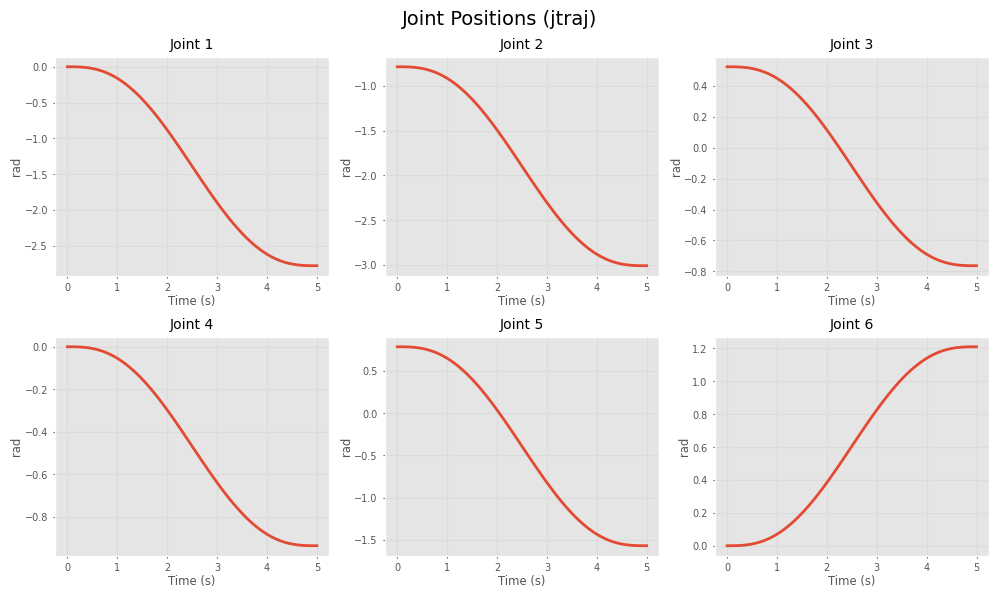

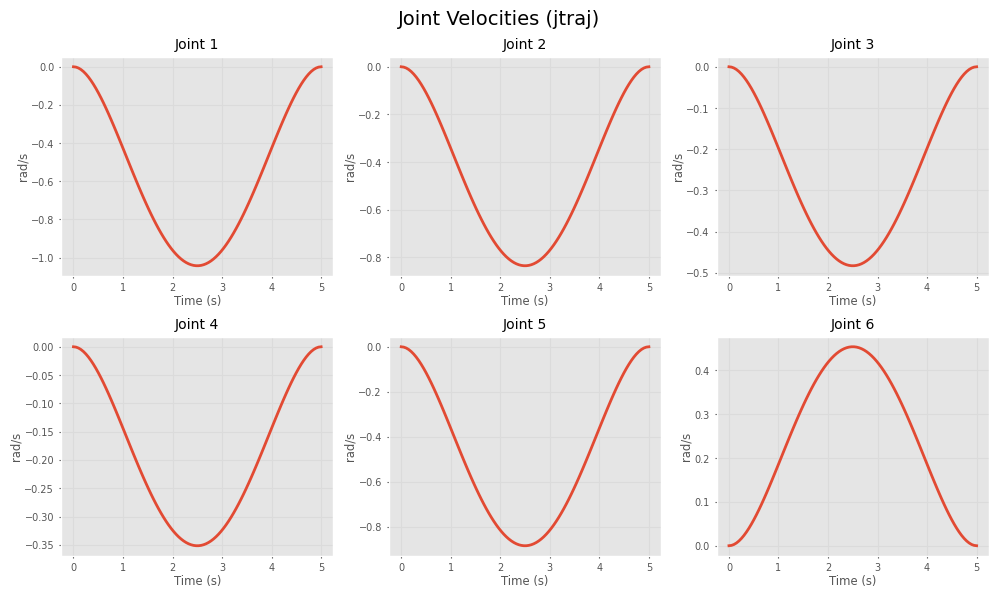

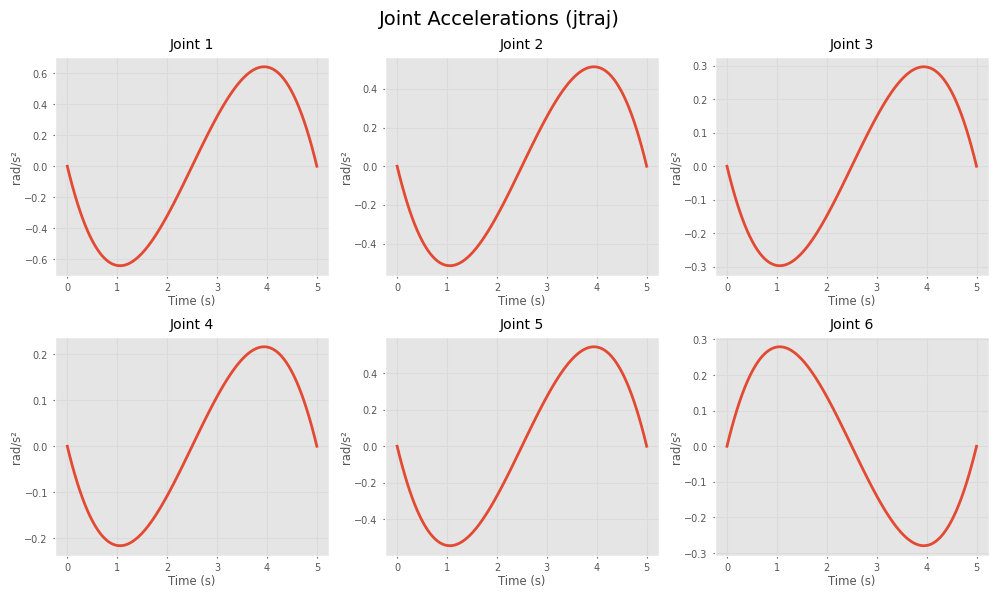

In [31]:
plot_joint_separate(t, traj1.q, "Joint Positions (jtraj)", "rad")
plot_joint_separate(t, traj1.qd, "Joint Velocities (jtraj)", "rad/s")
plot_joint_separate(t, traj1.qdd, "Joint Accelerations (jtraj)", "rad/s²")

##Cartesian trajectory

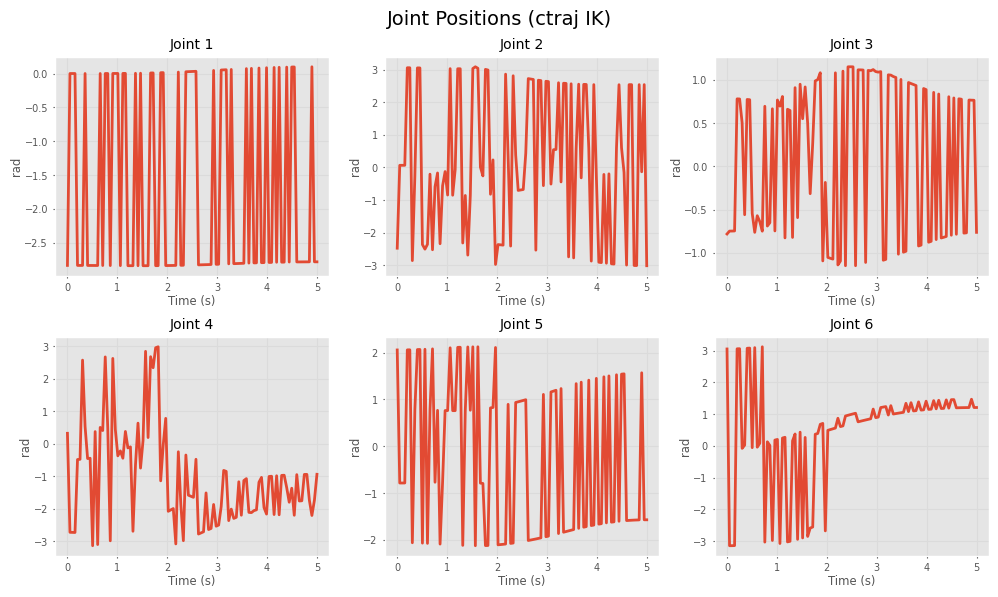

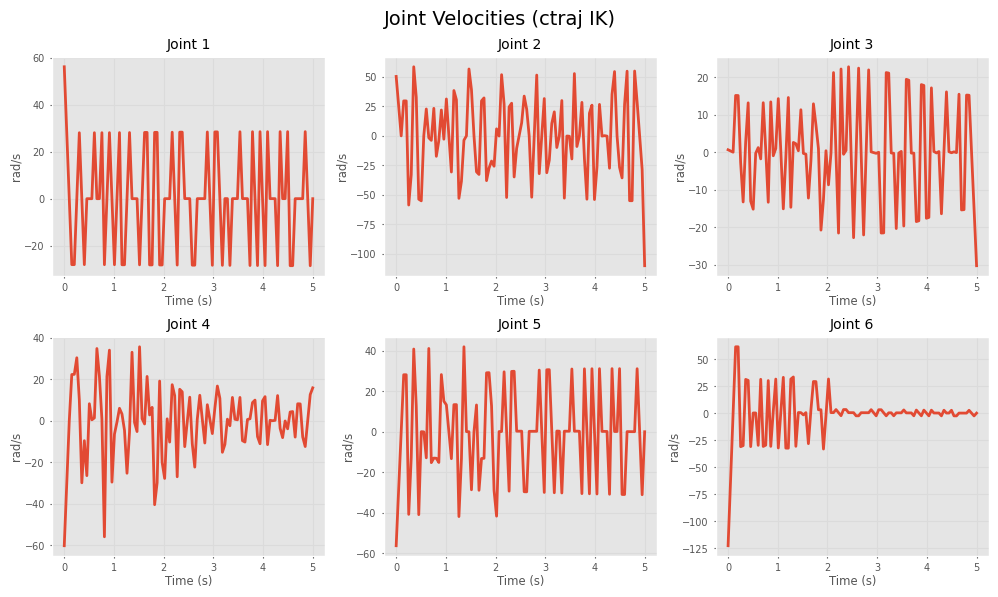

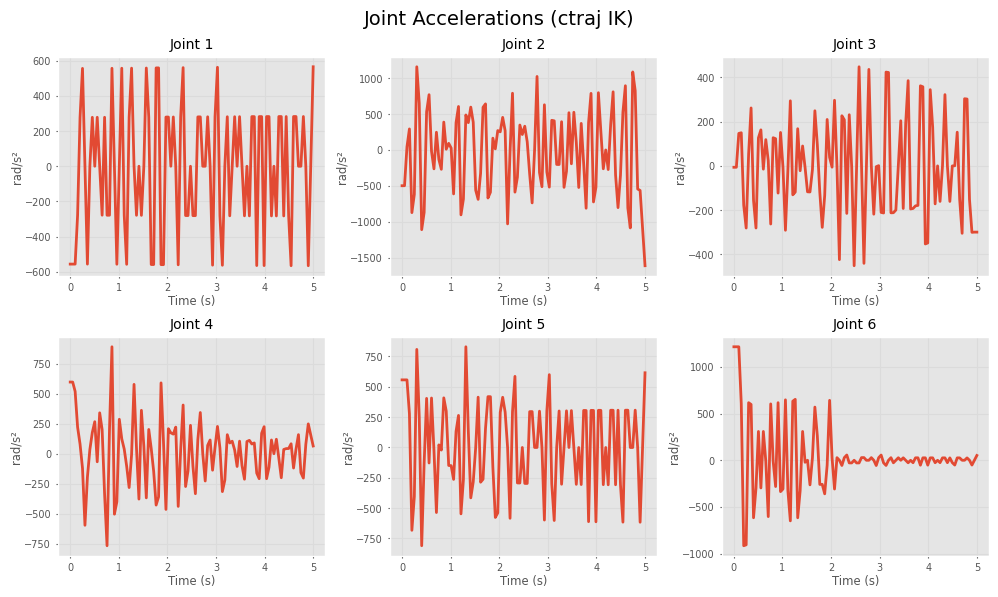

In [29]:
plot_joint_separate(t, traj2_q, "Joint Positions (ctraj IK)", "rad")
plot_joint_separate(t, qd2, "Joint Velocities (ctraj IK)", "rad/s")
plot_joint_separate(t, qdd2, "Joint Accelerations (ctraj IK)", "rad/s²")

##Linear interpolation

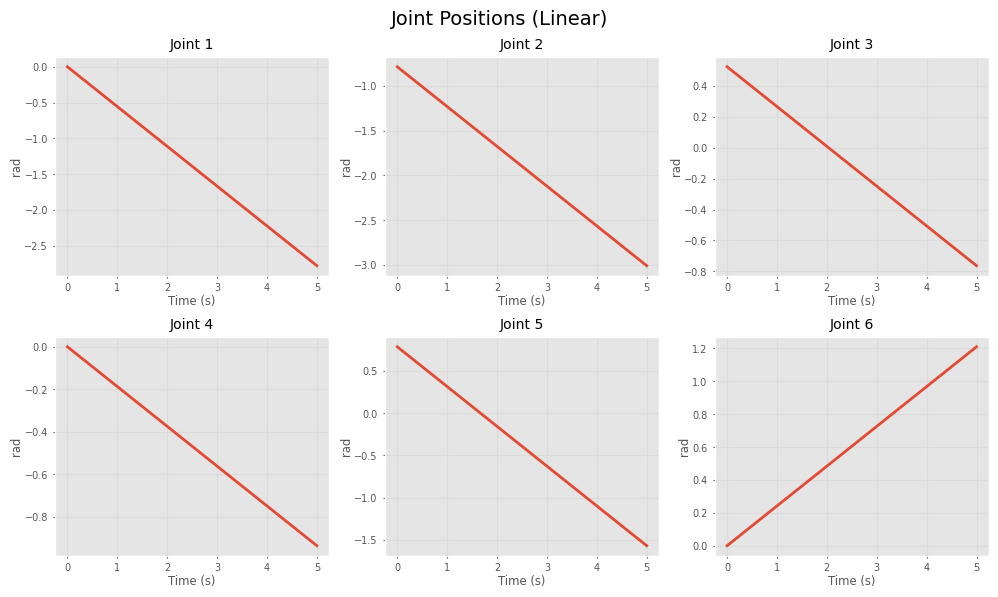

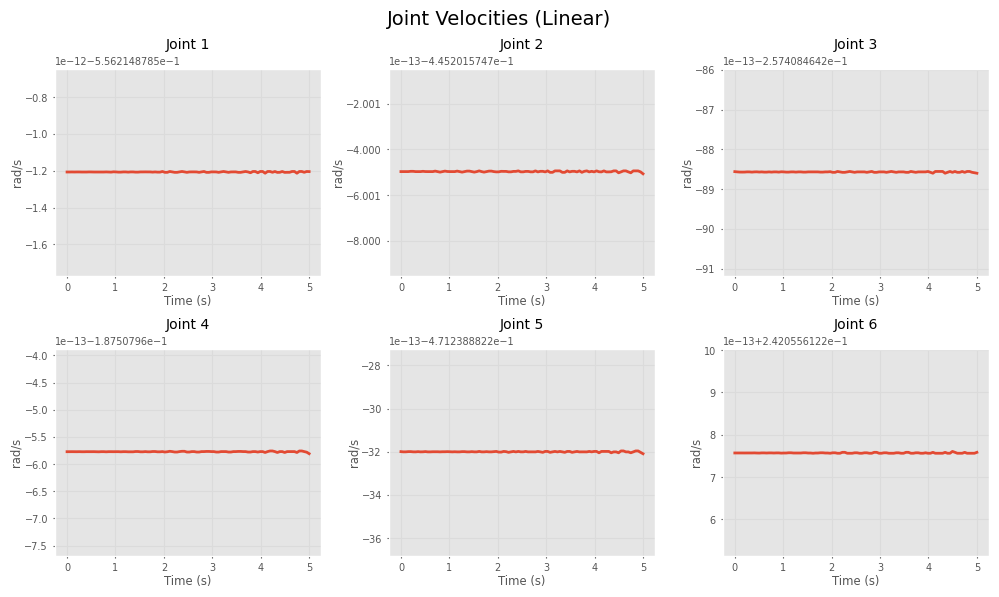

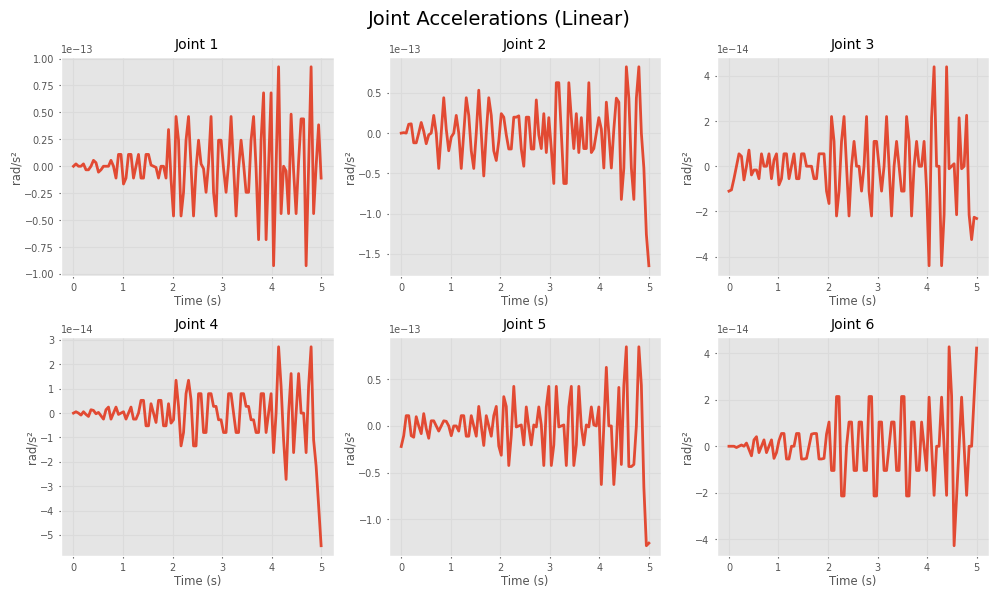

In [30]:
plot_joint_separate(t, traj3_q, "Joint Positions (Linear)", "rad")
plot_joint_separate(t, qd3, "Joint Velocities (Linear)", "rad/s")
plot_joint_separate(t, qdd3, "Joint Accelerations (Linear)", "rad/s²")